# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MuhammadTalha-pk/ML-Internship-Task1/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

**Research question:** Can historical Google Search Console performance signals, known by the end of a month, identify and rank content pages that are at higher risk of a meaningful decline in search visibility during the following month?

**Target decision:** The analysis supports the decision of which content pages an editor should review first. The output will be a ranked page-review queue with an estimated future-decline risk score. It is decision-support only; a high-risk page is not automatically refreshed.

**Unit of analysis:** One pseudonymized content page at one monthly prediction date.

**Provisional outcome:** A page will be treated as a future decline when its average daily impressions in the following calendar month are at least 30% lower than its average daily impressions in the prediction month. The 30% threshold will be checked on development data before the final holdout evaluation.
Cost of errors: A false positive wastes reviewer time and may send a healthy page for unnecessary investigation. A false negative is more costly when an important page declines but is not surfaced early for review.

**Why ML may help:** Search decline may depend on several signals at the same time, including visibility, clicks, CTR, ranking position, activity consistency, and recent momentum. A learned model may combine these signals more effectively than a single fixed rule, but it must be compared with a transparent baseline on the same future-period test set.

**Claim boundary:** This project predicts observed future performance in the FlyRank dataset. It does not claim to predict Google’s algorithm, prove why a page declined, or show that refreshing content causes performance to improve.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

**Data release and table:** This capstone uses the full FlyRank internship warehouse release from Hugging Face. The main source is fact_content_daily_performance, whose daily grain is report date × pseudonymized client × pseudonymized content item. I aggregate the daily rows to one page per calendar month before modeling.

**Time windows:** December 2025 is used only as historical context for lagged features. January, February, and March 2026 are development/training prediction months. April 2026 is the validation prediction month. May 2026 is the sealed final-test prediction month, and June 2026 is used only as its future outcome window. June information will not be used to choose features, thresholds, baseline logic, or models.

**Availability rule:** Search Console measurements are included only when gsc_data_available IS TRUE. I do not interpret unavailable measurements as genuine zeros.

**Public-safety and exclusions:** client_hash_id and content_hash_id are retained only for joining, grouping, and validation; they are not predictive features. Client names, domains, URLs, raw private queries, credentials, product flags, future-window values, and label-derived fields such as trend_direction and trend_pct are excluded from model inputs.

**Population note:** A later modeling step will require enough observed days in both the feature and outcome months so that the future-decline label is based on meaningful coverage. Because outcome-month coverage affects which rows can receive a reliable label, this selection will be disclosed as a limitation rather than hidden.

In [2]:
!pip -q install -U duckdb huggingface_hub pyarrow

import os
import json
import duckdb
import pandas as pd
import numpy as np

from google.colab import userdata

# Hugging Face token stays in Colab Secrets.
os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")

con = duckdb.connect()

con.execute("INSTALL httpfs")
con.execute("LOAD httpfs")

con.execute("""
CREATE OR REPLACE SECRET hf (
    TYPE huggingface,
    PROVIDER credential_chain
)
""")

print("DuckDB + Hugging Face connection ready.")

DuckDB + Hugging Face connection ready.


In [6]:
# ---------------------------------------------------------
# Monthly GSC panel
# December 2025 = lag/context month
# January-May 2026 = prediction months
# June 2026 = sealed final outcome month
# ---------------------------------------------------------

months = [
    "2025-12",
    "2026-01",
    "2026-02",
    "2026-03",
    "2026-04",
    "2026-05",
    "2026-06",
]

paths = [
    f"hf://datasets/FlyRank/internship-warehouse/"
    f"fact_content_daily_performance/month={m}/data_0.parquet"
    for m in months
]

paths_sql = ", ".join(f"'{p}'" for p in paths)

monthly_gsc = con.sql(f"""
SELECT
    CAST(DATE_TRUNC('month', report_date) AS DATE) AS prediction_month,

    client_hash_id,
    content_hash_id,

    COUNT(*) AS gsc_available_days,

    SUM(gsc_impressions) AS impressions_month,
    SUM(gsc_clicks) AS clicks_month,

    AVG(gsc_impressions) AS avg_daily_impressions,
    AVG(gsc_clicks) AS avg_daily_clicks,

    100.0 * SUM(gsc_clicks)
        / NULLIF(SUM(gsc_impressions), 0)
        AS ctr_pct,

    SUM(gsc_sum_position) * 1.0
        / NULLIF(SUM(gsc_impressions), 0)
        AS avg_position,

    COUNT(*) FILTER (
        WHERE gsc_impressions > 0
    ) AS days_with_impressions

FROM read_parquet([{paths_sql}])

WHERE gsc_data_available IS TRUE

GROUP BY 1, 2, 3
""").df()

monthly_gsc["prediction_month"] = pd.to_datetime(
    monthly_gsc["prediction_month"]
)

print("Monthly aggregate rows:", len(monthly_gsc))
print(
    "Earliest month:",
    monthly_gsc["prediction_month"].min().date()
)
print(
    "Latest month:",
    monthly_gsc["prediction_month"].max().date()
)

coverage = (
    monthly_gsc
    .groupby("prediction_month")
    .agg(
        pages=("content_hash_id", "size"),
        clients=("client_hash_id", "nunique"),
        median_available_days=("gsc_available_days", "median"),
    )
    .reset_index()
)

coverage

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Monthly aggregate rows: 1202786
Earliest month: 2025-12-01
Latest month: 2026-06-01


,prediction_month,pages,clients,median_available_days
0,2025-12-01,109639,38,23.0
1,2026-01-01,121544,37,25.0
2,2026-02-01,153559,46,20.0
3,2026-03-01,176738,47,26.0
4,2026-04-01,194760,51,25.0
5,2026-05-01,237910,56,22.0
6,2026-06-01,208636,55,23.0


In [7]:
os.makedirs("work/outputs", exist_ok=True)

cache_path = "work/outputs/capstone_monthly_gsc.parquet"

monthly_gsc.to_parquet(
    cache_path,
    index=False
)

print("Cached:", cache_path)
print("Cached rows:", len(monthly_gsc))

Cached: work/outputs/capstone_monthly_gsc.parquet
Cached rows: 1202786


**Aggregation check:** The large daily warehouse is not loaded into pandas. DuckDB filters and aggregates the remote Parquet data first, and pandas receives only the monthly page-level result. This keeps the modeling frame small and reproducible while avoiding repeated scans of the full daily table. June 2026 remains reserved as the final outcome month and is not used for model selection.

**Coverage check:** The monthly panel is unbalanced: both the number of observed pages and the number of clients change over time, and median GSC coverage varies between months. Therefore, the modeling population will require sufficient observed days rather than assuming every page has complete monthly history. For development, I require at least 20 GSC-available days in the previous month, prediction month, and outcome month. I also require at least 100 impressions in both historical feature months to reduce unstable momentum estimates from extremely low-volume pages. No minimum future impressions threshold is applied because doing so would remove genuine declines.

In [8]:
# ---------------------------------------------------------
# Build development prediction pairs
#
# Previous month + prediction month = features
# Following month = outcome
#
# Development only:
# Jan -> Feb
# Feb -> Mar
# Mar -> Apr
# Apr -> May
#
# May -> June remains SEALED and is NOT built yet.
# ---------------------------------------------------------

KEYS = ["client_hash_id", "content_hash_id"]

MONTH_COLS = [
    "gsc_available_days",
    "impressions_month",
    "clicks_month",
    "avg_daily_impressions",
    "avg_daily_clicks",
    "ctr_pct",
    "avg_position",
    "days_with_impressions",
]


def build_prediction_pair(panel, prediction_month):
    prediction_month = pd.Timestamp(prediction_month)

    previous_month = prediction_month - pd.DateOffset(months=1)
    outcome_month = prediction_month + pd.DateOffset(months=1)

    # Current prediction-month information
    current = panel[
        panel["prediction_month"] == prediction_month
    ][KEYS + MONTH_COLS].copy()

    current = current.rename(
        columns={
            col: f"current_{col}"
            for col in MONTH_COLS
        }
    )

    # Previous month — used only for historical momentum
    previous = panel[
        panel["prediction_month"] == previous_month
    ][KEYS + MONTH_COLS].copy()

    previous = previous.rename(
        columns={
            col: f"previous_{col}"
            for col in MONTH_COLS
        }
    )

    # Following month — used only for the outcome label
    future = panel[
        panel["prediction_month"] == outcome_month
    ][KEYS + MONTH_COLS].copy()

    future = future.rename(
        columns={
            col: f"future_{col}"
            for col in MONTH_COLS
        }
    )

    frame = (
        current
        .merge(previous, on=KEYS, how="inner")
        .merge(future, on=KEYS, how="inner")
    )

    # ----------------------------
    # Coverage / stability filters
    # ----------------------------
    frame = frame[
        (frame["previous_gsc_available_days"] >= 20)
        & (frame["current_gsc_available_days"] >= 20)
        & (frame["future_gsc_available_days"] >= 20)
        & (frame["previous_impressions_month"] >= 100)
        & (frame["current_impressions_month"] >= 100)
    ].copy()

    # ----------------------------
    # Safe features
    # ----------------------------

    frame["log_avg_daily_impressions"] = np.log1p(
        frame["current_avg_daily_impressions"]
    )

    frame["log_avg_daily_clicks"] = np.log1p(
        frame["current_avg_daily_clicks"]
    )

    frame["current_ctr_pct_feature"] = (
        frame["current_ctr_pct"]
    )

    frame["current_avg_position_feature"] = (
        frame["current_avg_position"]
    )

    frame["impression_day_ratio"] = (
        frame["current_days_with_impressions"]
        / frame["current_gsc_available_days"]
    )

    frame["impression_momentum_log"] = (
        np.log1p(frame["current_avg_daily_impressions"])
        - np.log1p(frame["previous_avg_daily_impressions"])
    )

    frame["click_momentum_log"] = (
        np.log1p(frame["current_avg_daily_clicks"])
        - np.log1p(frame["previous_avg_daily_clicks"])
    )

    frame["position_change"] = (
        frame["current_avg_position"]
        - frame["previous_avg_position"]
    )

    frame["ctr_change"] = (
        frame["current_ctr_pct"]
        - frame["previous_ctr_pct"]
    )

    # ----------------------------
    # FUTURE label
    # Following month is never a feature
    # ----------------------------
    frame["future_decline"] = (
        frame["future_avg_daily_impressions"]
        <= 0.70 * frame["current_avg_daily_impressions"]
    ).astype(int)

    frame["prediction_month"] = prediction_month
    frame["outcome_month"] = outcome_month

    return frame


development_months = [
    "2026-01-01",
    "2026-02-01",
    "2026-03-01",
    "2026-04-01",
]

development_frames = [
    build_prediction_pair(monthly_gsc, month)
    for month in development_months
]

dev_df = pd.concat(
    development_frames,
    ignore_index=True
)

# Time-aware split:
# Jan-March prediction months = training
# April prediction month = validation
dev_df["split"] = np.where(
    dev_df["prediction_month"] < pd.Timestamp("2026-04-01"),
    "train",
    "validation"
)

print("Development rows:", len(dev_df))
print(
    "Training rows:",
    int((dev_df["split"] == "train").sum())
)
print(
    "Validation rows:",
    int((dev_df["split"] == "validation").sum())
)

development_summary = (
    dev_df
    .groupby(
        ["prediction_month", "outcome_month", "split"]
    )
    .agg(
        rows=("content_hash_id", "size"),
        clients=("client_hash_id", "nunique"),
        decline_rate=("future_decline", "mean")
    )
    .reset_index()
)

development_summary["decline_rate"] = (
    development_summary["decline_rate"].round(3)
)

development_summary

Development rows: 239863
Training rows: 161149
Validation rows: 78714


,prediction_month,outcome_month,split,rows,clients,decline_rate
0,2026-01-01,2026-02-01,train,46967,25,0.106
1,2026-02-01,2026-03-01,train,53144,24,0.153
2,2026-03-01,2026-04-01,train,61038,24,0.413
3,2026-04-01,2026-05-01,validation,78714,32,0.464


In [9]:
dev_cache_path = "work/outputs/capstone_dev_frame.parquet"

dev_df.to_parquet(
    dev_cache_path,
    index=False
)

print("Development frame cached:", dev_cache_path)
print("Development rows cached:", len(dev_df))
print("Sealed May -> June test frame has NOT been built.")

Development frame cached: work/outputs/capstone_dev_frame.parquet
Development rows cached: 239863
Sealed May -> June test frame has NOT been built.


**Development target check:** The provisional 30% decline label shows substantial variation across prediction months, so I will test several decline thresholds using development data only before freezing the target. This check is descriptive: it does not use or inspect the sealed June outcome. The goal is to choose a threshold that represents a meaningful decline while preserving enough positive examples for honest model training and evaluation.

In [10]:
# ---------------------------------------------------------
# Target sensitivity check — DEVELOPMENT DATA ONLY
# June remains sealed.
# ---------------------------------------------------------

dev_df["future_to_current_ratio"] = (
    dev_df["future_avg_daily_impressions"]
    / dev_df["current_avg_daily_impressions"]
)

threshold_results = []

for decline_threshold in [0.20, 0.30, 0.40]:
    label_name = f"decline_{int(decline_threshold * 100)}pct"

    dev_df[label_name] = (
        dev_df["future_to_current_ratio"]
        <= (1.0 - decline_threshold)
    ).astype(int)

    summary = (
        dev_df
        .groupby("prediction_month")
        .agg(
            rows=("content_hash_id", "size"),
            positive_rate=(label_name, "mean")
        )
        .reset_index()
    )

    summary["decline_threshold"] = (
        f"{int(decline_threshold * 100)}%"
    )

    threshold_results.append(summary)

threshold_sensitivity = pd.concat(
    threshold_results,
    ignore_index=True
)

threshold_sensitivity["positive_rate"] = (
    threshold_sensitivity["positive_rate"].round(3)
)

threshold_sensitivity[
    [
        "decline_threshold",
        "prediction_month",
        "rows",
        "positive_rate"
    ]
]

,decline_threshold,prediction_month,rows,positive_rate
0,20%,2026-01-01,46967,0.157
1,20%,2026-02-01,53144,0.231
2,20%,2026-03-01,61038,0.519
3,20%,2026-04-01,78714,0.558
4,30%,2026-01-01,46967,0.106
5,30%,2026-02-01,53144,0.153
6,30%,2026-03-01,61038,0.413
7,30%,2026-04-01,78714,0.464
8,40%,2026-01-01,46967,0.071
9,40%,2026-02-01,53144,0.096


In [11]:
# Distribution of future-vs-current impression change
# Development data only

ratio_summary = (
    dev_df
    .groupby("prediction_month")
    ["future_to_current_ratio"]
    .agg(
        n="size",
        q10=lambda x: x.quantile(0.10),
        q25=lambda x: x.quantile(0.25),
        median="median",
        q75=lambda x: x.quantile(0.75),
        q90=lambda x: x.quantile(0.90)
    )
    .reset_index()
)

for col in ["q10", "q25", "median", "q75", "q90"]:
    ratio_summary[col] = ratio_summary[col].round(3)

ratio_summary

,prediction_month,n,q10,q25,median,q75,q90
0,2026-01-01,46967,0.685,0.936,1.266,1.780,2.553
1,2026-02-01,53144,0.608,0.822,1.089,1.466,1.962
2,2026-03-01,61038,0.361,0.546,0.782,1.092,1.545
3,2026-04-01,78714,0.313,0.480,0.739,1.027,1.377


**Target decision:** I freeze the future-decline definition at a 30% reduction in average daily impressions. On development data, a 20% threshold becomes a majority-class event in the later months, while a 40% threshold produces relatively few positive examples in the earlier months. The 30% definition is a middle ground: it represents a substantial change while retaining enough positive cases for modeling. This decision is made before opening the June holdout.

**Temporal shift:** The outcome distribution changes substantially across development periods. Earlier periods show lower decline rates, while March→April and April→May show much higher rates. I treat this as an observed time shift rather than assuming one stable base rate across the whole dataset. The final evaluation will therefore use a future holdout rather than a random row split.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

**Prediction design:** Features are calculated only from the prediction month and the month immediately before it. The label is measured only in the following month. This creates a strict past → prediction moment → future timeline.

**Final target:** future_decline = 1 when average daily impressions in the following month are at least 30% lower than average daily impressions in the prediction month; otherwise it is 0.

**Features: **The model uses nine historical signals: log average daily impressions, log average daily clicks, current CTR, current average position, the share of observed days with impressions, impression momentum, click momentum, position change, and CTR change. Pseudonymous IDs are retained only for grouping and audit purposes and are never predictive inputs.

**Validation design:** January–March 2026 prediction rows are used for training and April 2026 prediction rows, whose outcome is May 2026, are used for validation. This time-aware split evaluates whether a model trained on earlier periods ranks decline risk in a later period.

**Baseline:** The transparent baseline prioritizes pages that already show negative impression momentum, with higher priority given to pages that also have greater current visibility. The baseline and learned models are evaluated on the same validation rows and the same future-decline target.

**Models:** I compare Logistic Regression as an interpretable learned model with Random Forest as a nonlinear model. Model selection is based on validation performance rather than training performance.

**Primary metric:** Precision@50 is the main decision metric because the practical question is which 50 pages should an editor review first. Precision@10, Precision@20, Average Precision, ROC-AUC, and the validation base rate are reported as supporting evidence.

**Leakage controls:** No future-month metric, label-derived column, product flag, client ID, or content ID is used as a feature. June remains unopened during development and model selection.

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, roc_auc_score
import json

RANDOM_SEED = 42

FEATURES = [
    "log_avg_daily_impressions",
    "log_avg_daily_clicks",
    "current_ctr_pct_feature",
    "current_avg_position_feature",
    "impression_day_ratio",
    "impression_momentum_log",
    "click_momentum_log",
    "position_change",
    "ctr_change",
]

TARGET = "future_decline"

train_df = dev_df[
    dev_df["split"] == "train"
].copy()

val_df = dev_df[
    dev_df["split"] == "validation"
].copy()

print("Features:", len(FEATURES))
print("Training rows:", len(train_df))
print("Validation rows:", len(val_df))
print(
    "Training base rate:",
    round(train_df[TARGET].mean(), 3)
)
print(
    "Validation base rate:",
    round(val_df[TARGET].mean(), 3)
)

missing_check = pd.DataFrame({
    "feature": FEATURES,
    "train_missing": [
        train_df[f].isna().sum()
        for f in FEATURES
    ],
    "validation_missing": [
        val_df[f].isna().sum()
        for f in FEATURES
    ],
})

missing_check

Features: 9
Training rows: 161149
Validation rows: 78714
Training base rate: 0.238
Validation base rate: 0.464


,feature,train_missing,validation_missing
0,log_avg_daily_impressions,0,0
1,log_avg_daily_clicks,0,0
2,current_ctr_pct_feature,0,0
3,current_avg_position_feature,0,0
4,impression_day_ratio,0,0
5,impression_momentum_log,0,0
6,click_momentum_log,0,0
7,position_change,0,0
8,ctr_change,0,0


In [13]:
def precision_at_k(y_true, scores, k):
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)

    order = np.argsort(-scores)

    k = min(k, len(order))

    return y_true[order[:k]].mean()


def metric_row(name, y_true, scores):
    return {
        "method": name,
        "base_rate": y_true.mean(),
        "precision_at_10": precision_at_k(
            y_true, scores, 10
        ),
        "precision_at_20": precision_at_k(
            y_true, scores, 20
        ),
        "precision_at_50": precision_at_k(
            y_true, scores, 50
        ),
        "average_precision": average_precision_score(
            y_true, scores
        ),
        "roc_auc": roc_auc_score(
            y_true, scores
        ),
    }


# Transparent baseline:
# larger recent negative momentum = more concern
# higher visibility = more review priority
val_df["baseline_score"] = (
    (-val_df["impression_momentum_log"]).clip(lower=0)
    * val_df["log_avg_daily_impressions"]
)

baseline_metrics = metric_row(
    "Transparent baseline",
    val_df[TARGET],
    val_df["baseline_score"]
)

pd.DataFrame([baseline_metrics]).round(3)

,method,base_rate,precision_at_10,precision_at_20,precision_at_50,average_precision,roc_auc
0,Transparent baseline,0.464,0.6,0.7,0.56,0.528,0.57


In [14]:
X_train = train_df[FEATURES]
y_train = train_df[TARGET]

X_val = val_df[FEATURES]
y_val = val_df[TARGET]


# -----------------------------------
# Model 1: Logistic Regression
# -----------------------------------

logistic_model = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=RANDOM_SEED
        )
    ),
])

logistic_model.fit(
    X_train,
    y_train
)

logistic_scores = logistic_model.predict_proba(
    X_val
)[:, 1]


# -----------------------------------
# Model 2: Random Forest
# -----------------------------------

rf_model = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "model",
        RandomForestClassifier(
            n_estimators=300,
            max_depth=8,
            min_samples_leaf=50,
            class_weight="balanced_subsample",
            random_state=RANDOM_SEED,
            n_jobs=-1
        )
    ),
])

rf_model.fit(
    X_train,
    y_train
)

rf_scores = rf_model.predict_proba(
    X_val
)[:, 1]


# -----------------------------------
# Honest comparison
# -----------------------------------

validation_results = pd.DataFrame([
    baseline_metrics,

    metric_row(
        "Logistic Regression",
        y_val,
        logistic_scores
    ),

    metric_row(
        "Random Forest",
        y_val,
        rf_scores
    ),
])

metric_cols = [
    "base_rate",
    "precision_at_10",
    "precision_at_20",
    "precision_at_50",
    "average_precision",
    "roc_auc",
]

validation_results[metric_cols] = (
    validation_results[metric_cols]
    .round(3)
)

validation_results

,method,base_rate,precision_at_10,precision_at_20,precision_at_50,average_precision,roc_auc
0,Transparent baseline,0.464,0.6,0.70,0.56,0.528,0.570
1,Logistic Regression,0.464,0.9,0.80,0.66,0.577,0.634
2,Random Forest,0.464,0.9,0.85,0.90,0.555,0.612


In [15]:
os.makedirs(
    "work/outputs",
    exist_ok=True
)

validation_metrics_path = (
    "work/outputs/"
    "capstone_validation_metrics.json"
)

validation_receipt = {
    "random_seed": RANDOM_SEED,
    "target_definition":
        "future average daily impressions "
        "at least 30% below prediction month",
    "training_prediction_months": [
        "2026-01",
        "2026-02",
        "2026-03"
    ],
    "validation_prediction_month":
        "2026-04",
    "validation_outcome_month":
        "2026-05",
    "features": FEATURES,
    "results":
        validation_results.to_dict(
            orient="records"
        )
}

with open(
    validation_metrics_path,
    "w"
) as f:
    json.dump(
        validation_receipt,
        f,
        indent=2
    )

print(
    "Saved:",
    validation_metrics_path
)
print(
    "June holdout still unopened."
)

Saved: work/outputs/capstone_validation_metrics.json
June holdout still unopened.


**Validation result:** The Random Forest achieved the strongest Precision@50 at 0.900, compared with 0.660 for Logistic Regression and 0.560 for the transparent baseline. This is the primary metric because the practical use case is a limited review queue. Logistic Regression performed better on broader ranking metrics, with higher Average Precision and ROC-AUC, so the Random Forest should not be described as universally better. Instead, it is selected because it performs best at the top of the ranked list, which is the decision point defined before modeling.
The validation base rate is 46.4%, substantially higher than the 23.8% training base rate. This shift indicates that decline prevalence changes over time, so random row-level validation would be less realistic than the time-aware split used here.

In [16]:
# ---------------------------------------------------------
# Validation audit before opening the sealed June holdout
# ---------------------------------------------------------

# Random Forest feature importance
rf_estimator = rf_model.named_steps["model"]

importance_df = pd.DataFrame({
    "feature": FEATURES,
    "importance": rf_estimator.feature_importances_
}).sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

importance_df["importance"] = (
    importance_df["importance"].round(4)
)

print("Random Forest feature importance:")
display(importance_df)


# Explicit leakage audit
forbidden_exact = {
    "future_decline",
    "client_hash_id",
    "content_hash_id",
    "trend_direction",
    "trend_pct",
}

future_features = [
    f for f in FEATURES
    if f.startswith("future_")
]

forbidden_used = [
    f for f in FEATURES
    if f in forbidden_exact
]

print("\nFeature count:", len(FEATURES))
print("Future-window features used:", future_features)
print("Forbidden fields used:", forbidden_used)
print(
    "Leakage audit passed:",
    len(future_features) == 0
    and len(forbidden_used) == 0
)

Random Forest feature importance:


,feature,importance
0,position_change,0.1910
1,current_ctr_pct_feature,0.1891
2,click_momentum_log,0.1691
3,impression_momentum_log,0.1413
4,log_avg_daily_impressions,0.1095
5,log_avg_daily_clicks,0.0887
6,current_avg_position_feature,0.0620
7,ctr_change,0.0493
8,impression_day_ratio,0.0000



Feature count: 9
Future-window features used: []
Forbidden fields used: []
Leakage audit passed: True


In [17]:
# ---------------------------------------------------------
# Top-50 validation review and concrete errors
# ---------------------------------------------------------

val_audit = val_df[
    [
        "client_hash_id",
        "content_hash_id",
        "prediction_month",
        "outcome_month",
        TARGET
    ] + FEATURES
].copy()

val_audit["rf_risk_score"] = rf_scores

val_audit = val_audit.sort_values(
    "rf_risk_score",
    ascending=False
).reset_index(drop=True)

val_audit["validation_rank"] = (
    np.arange(1, len(val_audit) + 1)
)

top50_rf = val_audit.head(50).copy()

print(
    "Top-50 true declines:",
    int(top50_rf[TARGET].sum())
)

print(
    "Top-50 false positives:",
    int((top50_rf[TARGET] == 0).sum())
)

print(
    "Top-50 Precision:",
    round(top50_rf[TARGET].mean(), 3)
)


# Highest-ranked false positives
false_positives = (
    val_audit[
        (val_audit["validation_rank"] <= 50)
        & (val_audit[TARGET] == 0)
    ]
    .head(3)
    .copy()
)

# Positive cases that just missed the top-50 cutoff
missed_declines = (
    val_audit[
        (val_audit["validation_rank"] > 50)
        & (val_audit[TARGET] == 1)
    ]
    .head(3)
    .copy()
)

error_columns = [
    "validation_rank",
    "content_hash_id",
    "rf_risk_score",
    TARGET,
    "log_avg_daily_impressions",
    "current_ctr_pct_feature",
    "current_avg_position_feature",
    "impression_momentum_log",
    "click_momentum_log",
    "position_change",
    "ctr_change",
]

print("\nThree top-50 false positives:")
display(
    false_positives[error_columns]
    .round(3)
)

print("\nThree true declines just below the top-50 queue:")
display(
    missed_declines[error_columns]
    .round(3)
)

Top-50 true declines: 45
Top-50 false positives: 5
Top-50 Precision: 0.9

Three top-50 false positives:


,validation_rank,content_hash_id,rf_risk_score,future_decline,log_avg_daily_impressions,current_ctr_pct_feature,current_avg_position_feature,impression_momentum_log,click_momentum_log,position_change,ctr_change
2,3,content_c75e0854ca14ce9e,0.760,0,4.495,0.00,4.555,1.653,-0.036,-4.424,-0.229
15,16,content_5d1af55a814e4b15,0.745,0,5.524,0.12,2.615,-0.892,-0.523,0.609,-0.075
19,20,content_bbbc96897e389334,0.741,0,3.777,0.00,2.086,1.454,0.000,-4.824,0.000



Three true declines just below the top-50 queue:


,validation_rank,content_hash_id,rf_risk_score,future_decline,log_avg_daily_impressions,current_ctr_pct_feature,current_avg_position_feature,impression_momentum_log,click_momentum_log,position_change,ctr_change
50,51,content_3173a35e388fdf30,0.729,1,4.699,0.0,3.306,1.393,0.000,-7.801,0.000
51,52,content_02b42a17d441af25,0.728,1,3.033,0.0,2.413,-0.032,-0.036,0.685,-0.181
52,53,content_e5e7979b449ff016,0.728,1,3.900,0.0,4.039,1.825,0.000,-23.929,0.000


In [18]:
selected_model_name = "Random Forest"
selected_model = rf_model

model_selection_receipt = {
    "selected_model": selected_model_name,
    "selection_metric": "precision_at_50",
    "validation_precision_at_50": 0.90,
    "validation_base_rate": 0.464,
    "random_seed": RANDOM_SEED,
    "feature_count": len(FEATURES),
    "june_holdout_opened": False,
    "selection_note":
        "Random Forest selected because it had the best "
        "pre-specified operational metric, Precision@50. "
        "Logistic Regression had stronger global ranking metrics."
}

with open(
    "work/outputs/capstone_model_selection.json",
    "w"
) as f:
    json.dump(
        model_selection_receipt,
        f,
        indent=2
    )

print("Selected model:", selected_model_name)
print("Selection metric: Precision@50")
print("June holdout still sealed: True")

Selected model: Random Forest
Selection metric: Precision@50
June holdout still sealed: True


**Pre-holdout interpretation:** The Random Forest relied most heavily on position change, current CTR, click momentum, and impression momentum. These importance values describe how the fitted model separated cases; they are not causal effects. The top-50 validation review contained 45 true declines and 5 false positives. Several false positives had improving recent visibility or position, showing that the nonlinear model can still assign high risk when other signals such as CTR or click behavior look unusual. Conversely, some true declines appeared immediately below the top-50 cutoff. This reinforces that the score is a ranking aid rather than a certain prediction for any individual page.
The model specification, nine-feature list, 30% target threshold, Random Forest hyperparameters, baseline formula, and Precision@50 selection criterion are now frozen before opening the June outcome.

In [19]:
# =========================================================
# SEALED FINAL TEST
#
# Prediction month: May 2026
# Outcome month: June 2026
#
# Model, features, target threshold and baseline logic
# were frozen BEFORE this cell was run.
# =========================================================

sealed_test_df = build_prediction_pair(
    monthly_gsc,
    "2026-05-01"
)

print("SEALED HOLDOUT OPENED.")
print("Test prediction month: 2026-05")
print("Test outcome month: 2026-06")
print("Sealed test rows:", len(sealed_test_df))
print(
    "Sealed test clients:",
    sealed_test_df["client_hash_id"].nunique()
)
print(
    "Sealed test base decline rate:",
    round(sealed_test_df[TARGET].mean(), 3)
)

SEALED HOLDOUT OPENED.
Test prediction month: 2026-05
Test outcome month: 2026-06
Sealed test rows: 78137
Sealed test clients: 39
Sealed test base decline rate: 0.544


In [20]:
from sklearn.base import clone

# ---------------------------------------------------------
# Final fit:
# use ALL development rows after model selection is frozen
# ---------------------------------------------------------

X_dev_all = dev_df[FEATURES]
y_dev_all = dev_df[TARGET]

X_test = sealed_test_df[FEATURES]
y_test = sealed_test_df[TARGET]

final_rf_model = clone(selected_model)

final_rf_model.fit(
    X_dev_all,
    y_dev_all
)

sealed_rf_scores = final_rf_model.predict_proba(
    X_test
)[:, 1]

print("Final Random Forest fitted on all development data.")
print("Development rows used:", len(dev_df))
print("Sealed test rows:", len(sealed_test_df))

Final Random Forest fitted on all development data.
Development rows used: 239863
Sealed test rows: 78137


In [21]:
# ---------------------------------------------------------
# Frozen transparent baseline
# EXACT SAME formula used during validation
# ---------------------------------------------------------

sealed_test_df["baseline_score"] = (
    (-sealed_test_df["impression_momentum_log"])
    .clip(lower=0)
    * sealed_test_df["log_avg_daily_impressions"]
)

sealed_baseline_scores = (
    sealed_test_df["baseline_score"].to_numpy()
)

print("Frozen baseline applied to sealed test.")

Frozen baseline applied to sealed test.


In [22]:
def final_metric_row(name, y_true, scores):
    base_rate = float(np.mean(y_true))
    p10 = float(precision_at_k(y_true, scores, 10))
    p20 = float(precision_at_k(y_true, scores, 20))
    p50 = float(precision_at_k(y_true, scores, 50))

    return {
        "method": name,
        "base_rate": base_rate,
        "precision_at_10": p10,
        "precision_at_20": p20,
        "precision_at_50": p50,
        "lift_at_50": (
            p50 / base_rate
            if base_rate > 0
            else np.nan
        ),
        "average_precision":
            average_precision_score(
                y_true,
                scores
            ),
        "roc_auc":
            roc_auc_score(
                y_true,
                scores
            ),
    }


sealed_results = pd.DataFrame([
    final_metric_row(
        "Transparent baseline",
        y_test,
        sealed_baseline_scores
    ),

    final_metric_row(
        "Frozen Random Forest",
        y_test,
        sealed_rf_scores
    ),
])

numeric_cols = [
    "base_rate",
    "precision_at_10",
    "precision_at_20",
    "precision_at_50",
    "lift_at_50",
    "average_precision",
    "roc_auc",
]

sealed_results[numeric_cols] = (
    sealed_results[numeric_cols]
    .round(3)
)

sealed_results

,method,base_rate,precision_at_10,precision_at_20,precision_at_50,lift_at_50,average_precision,roc_auc
0,Transparent baseline,0.544,0.7,0.70,0.62,1.139,0.574,0.524
1,Frozen Random Forest,0.544,0.8,0.85,0.82,1.507,0.644,0.617


In [23]:
sealed_metrics_path = (
    "work/outputs/"
    "capstone_sealed_test_metrics.json"
)

sealed_receipt = {
    "status": "sealed holdout opened once after model selection",
    "prediction_month": "2026-05",
    "outcome_month": "2026-06",
    "target_definition":
        "future average daily impressions "
        "at least 30% below prediction month",
    "selected_model": "Random Forest",
    "selection_metric": "precision_at_50",
    "random_seed": RANDOM_SEED,
    "features": FEATURES,
    "development_rows": int(len(dev_df)),
    "sealed_test_rows": int(len(sealed_test_df)),
    "sealed_test_clients":
        int(
            sealed_test_df[
                "client_hash_id"
            ].nunique()
        ),
    "sealed_test_base_rate":
        round(
            float(y_test.mean()),
            6
        ),
    "results":
        sealed_results.to_dict(
            orient="records"
        )
}

with open(
    sealed_metrics_path,
    "w"
) as f:
    json.dump(
        sealed_receipt,
        f,
        indent=2
    )

print("Saved sealed receipt:")
print(sealed_metrics_path)
print(
    "Do not retune the model using "
    "these June results."
)

Saved sealed receipt:
work/outputs/capstone_sealed_test_metrics.json
Do not retune the model using these June results.


In [24]:
final_queue = sealed_test_df[
    [
        "client_hash_id",
        "content_hash_id",
        "prediction_month",
        "outcome_month",
        "current_avg_daily_impressions",
        "current_avg_daily_clicks",
        "current_ctr_pct_feature",
        "current_avg_position_feature",
        "impression_momentum_log",
        "click_momentum_log",
        "position_change",
        "ctr_change",
        TARGET,
    ]
].copy()

final_queue["future_decline_risk"] = (
    sealed_rf_scores
)

final_queue = final_queue.sort_values(
    "future_decline_risk",
    ascending=False
).reset_index(drop=True)

final_queue["rank"] = (
    np.arange(
        1,
        len(final_queue) + 1
    )
)

final_queue["action_label"] = np.where(
    final_queue["rank"] <= 50,
    "priority_review",
    "monitor"
)

final_queue[
    [
        "rank",
        "content_hash_id",
        "future_decline_risk",
        "action_label",
        "current_avg_daily_impressions",
        "current_ctr_pct_feature",
        "current_avg_position_feature",
        "impression_momentum_log",
        "position_change",
    ]
].head(10).round(3)

,rank,content_hash_id,future_decline_risk,action_label,current_avg_daily_impressions,current_ctr_pct_feature,current_avg_position_feature,impression_momentum_log,position_change
0,1,content_12d95d7f8c2728ad,0.783,priority_review,104.310,0.033,2.980,-0.667,0.597
1,2,content_b63094bd417908e9,0.782,priority_review,518.677,0.044,35.950,-0.571,-5.594
2,3,content_6a49f91a2da31c46,0.778,priority_review,402.129,0.032,2.849,-0.925,0.471
3,4,content_b9acd1ebff7d34ff,0.775,priority_review,156.484,0.021,2.558,-1.839,0.493
4,5,content_d2def933ed902af2,0.770,priority_review,418.903,0.023,40.732,-0.872,2.630
5,6,content_a714311e4cf2bbda,0.769,priority_review,88.742,0.109,3.586,-0.923,0.791
6,7,content_5e20282db1d5b814,0.769,priority_review,703.677,0.060,2.688,-1.453,0.389
7,8,content_e986eb3ab70fcee6,0.769,priority_review,300.194,0.021,33.748,-0.949,2.491
8,9,content_f36d529e22feabc6,0.768,priority_review,118.645,0.082,3.405,-0.542,0.741
9,10,content_e23909f72d8ba18e,0.766,priority_review,301.323,0.032,28.657,-0.992,3.591


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

**Sealed-test result:** After model selection was completed, the frozen Random Forest was retrained on all development rows and evaluated once on the May 2026 prediction frame with June 2026 as the unseen outcome month. The June holdout contained 78,137 eligible page-month rows across 39 pseudonymized clients, with a future-decline base rate of 54.4%.
On the pre-specified primary metric, Precision@50, the transparent baseline achieved 0.620 while the frozen Random Forest achieved 0.820. Therefore, 41 of the model's top 50 review candidates met the future-decline definition, compared with 31 of the baseline's top 50. The model's Precision@50 was approximately 1.51 times the test-set base rate.
The model also exceeded the baseline on Precision@10 (0.800 vs 0.700), Precision@20 (0.850 vs 0.700), Average Precision (0.644 vs 0.574), and ROC-AUC (0.617 vs 0.524). The validation Precision@50 had been 0.900, so the lower sealed-test result of 0.820 shows some expected temporal generalization loss. I report the sealed result as the headline result rather than the higher validation score.
These results show that, in this FlyRank holdout period, the learned ranking concentrated future declines near the top of the review queue more effectively than the transparent baseline. They do not establish why those pages declined or that any particular intervention would improve them.

## 5. Limitations

*What this work cannot claim.*

**Limitations:** This project measures associations and out-of-time predictive ranking, not causation. A high model score does not mean that refreshing a page will improve its search performance, and the analysis does not model or claim to identify Google's ranking algorithm.
The data form an unbalanced panel: clients enter the dataset at different times and monthly coverage changes substantially. The eligible modeling population also requires at least 20 GSC-available days in the previous, prediction, and future months. Requiring sufficient future-month coverage makes the label more reliable, but it means the evaluated population is partly defined using outcome-period availability and may not represent pages that disappear or have very sparse future measurement.
The prevalence of the decline label changed substantially over time: the training base rate was 23.8%, validation was 46.4%, and the sealed test was 54.4%. This temporal shift limits how confidently a single performance number can be generalized to other periods or portfolios.
The 30% decline threshold is a practical proxy rather than a natural law. It was selected using development data before the June holdout was opened. Different thresholds would define a different decision problem.
The Random Forest risk score is used for ranking and should not be interpreted as a perfectly calibrated probability. Feature importance describes what the model relied on for prediction; it does not show causal effects or the direction of an intervention.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [25]:
# ---------------------------------------------------------
# Final action queue with public-safe reason codes
# Model itself is NOT changed here.
# ---------------------------------------------------------

def make_reason_code(row):
    imp_down = row["impression_momentum_log"] < 0
    clicks_down = row["click_momentum_log"] < 0
    position_worse = row["position_change"] > 0

    if imp_down and clicks_down and position_worse:
        return "visibility_clicks_and_position_weakened"

    if imp_down and position_worse:
        return "visibility_down_position_weaker"

    if imp_down and clicks_down:
        return "visibility_and_clicks_down"

    if imp_down:
        return "visibility_momentum_down"

    if position_worse:
        return "position_weaker"

    return "multi_signal_model_risk"


final_queue["reason_code"] = (
    final_queue.apply(
        make_reason_code,
        axis=1
    )
)

final_queue["recommended_action"] = np.where(
    final_queue["rank"] <= 50,
    "review_page_before_refresh_decision",
    "monitor"
)

public_queue_columns = [
    "rank",
    "content_hash_id",
    "future_decline_risk",
    "reason_code",
    "recommended_action",
    "current_avg_daily_impressions",
    "current_ctr_pct_feature",
    "current_avg_position_feature",
    "impression_momentum_log",
    "click_momentum_log",
    "position_change",
]

top50_recommendations = (
    final_queue[
        public_queue_columns
    ]
    .head(50)
    .copy()
)

display(
    top50_recommendations
    .head(10)
    .round(3)
)

queue_path = (
    "work/outputs/"
    "capstone_ranked_recommendations.csv"
)

top50_recommendations.to_csv(
    queue_path,
    index=False
)

print("Saved ranked recommendations:", queue_path)

,rank,content_hash_id,future_decline_risk,reason_code,recommended_action,current_avg_daily_impressions,current_ctr_pct_feature,current_avg_position_feature,impression_momentum_log,click_momentum_log,position_change
0,1,content_12d95d7f8c2728ad,0.783,visibility_clicks_and_position_weakened,review_page_before_refresh_decision,104.310,0.033,2.980,-0.667,-0.202,0.597
1,2,content_b63094bd417908e9,0.782,visibility_momentum_down,review_page_before_refresh_decision,518.677,0.044,35.950,-0.571,0.204,-5.594
2,3,content_6a49f91a2da31c46,0.778,visibility_down_position_weaker,review_page_before_refresh_decision,402.129,0.032,2.849,-0.925,0.026,0.471
3,4,content_b9acd1ebff7d34ff,0.775,visibility_clicks_and_position_weakened,review_page_before_refresh_decision,156.484,0.021,2.558,-1.839,-0.281,0.493
4,5,content_d2def933ed902af2,0.770,visibility_down_position_weaker,review_page_before_refresh_decision,418.903,0.023,40.732,-0.872,0.060,2.630
5,6,content_a714311e4cf2bbda,0.769,visibility_clicks_and_position_weakened,review_page_before_refresh_decision,88.742,0.109,3.586,-0.923,-0.117,0.791
6,7,content_5e20282db1d5b814,0.769,visibility_clicks_and_position_weakened,review_page_before_refresh_decision,703.677,0.060,2.688,-1.453,-0.274,0.389
7,8,content_e986eb3ab70fcee6,0.769,visibility_down_position_weaker,review_page_before_refresh_decision,300.194,0.021,33.748,-0.949,0.063,2.491
8,9,content_f36d529e22feabc6,0.768,visibility_clicks_and_position_weakened,review_page_before_refresh_decision,118.645,0.082,3.405,-0.542,-0.090,0.741
9,10,content_e23909f72d8ba18e,0.766,visibility_down_position_weaker,review_page_before_refresh_decision,301.323,0.032,28.657,-0.992,0.060,3.591


Saved ranked recommendations: work/outputs/capstone_ranked_recommendations.csv


**Action playbook:** The top 50 pages form a priority-review queue, not an automatic refresh list. An editor should inspect the page, query intent, search-result presentation, competing content, seasonality, and recent content changes before deciding what action to take. The reason code summarizes visible historical signals associated with the ranking, but it is not a causal explanation generated by the model.
Pages ranked outside the top 50 remain monitoring candidates rather than confirmed healthy pages. The queue is most useful when reviewer capacity is limited and the goal is to concentrate attention on pages that the model ranks as having comparatively higher future-decline risk.

In [26]:
sealed_audit = final_queue.copy()

top50_sealed = sealed_audit.head(50)

print(
    "Top-50 true declines:",
    int(top50_sealed[TARGET].sum())
)

print(
    "Top-50 false positives:",
    int((top50_sealed[TARGET] == 0).sum())
)

sealed_false_positives = (
    sealed_audit[
        (sealed_audit["rank"] <= 50)
        & (sealed_audit[TARGET] == 0)
    ]
    .head(3)
)

sealed_near_misses = (
    sealed_audit[
        (sealed_audit["rank"] > 50)
        & (sealed_audit[TARGET] == 1)
    ]
    .head(3)
)

audit_cols = [
    "rank",
    "content_hash_id",
    "future_decline_risk",
    TARGET,
    "current_avg_daily_impressions",
    "current_ctr_pct_feature",
    "current_avg_position_feature",
    "impression_momentum_log",
    "click_momentum_log",
    "position_change",
]

print("\nThree sealed-test false positives:")
display(
    sealed_false_positives[
        audit_cols
    ].round(3)
)

print("\nThree true declines immediately below top 50:")
display(
    sealed_near_misses[
        audit_cols
    ].round(3)
)

Top-50 true declines: 41
Top-50 false positives: 9

Three sealed-test false positives:


,rank,content_hash_id,future_decline_risk,future_decline,current_avg_daily_impressions,current_ctr_pct_feature,current_avg_position_feature,impression_momentum_log,click_momentum_log,position_change
1,2,content_b63094bd417908e9,0.782,0,518.677,0.044,35.950,-0.571,0.204,-5.594
7,8,content_e986eb3ab70fcee6,0.769,0,300.194,0.021,33.748,-0.949,0.063,2.491
16,17,content_4cd8612438c6c2cc,0.764,0,53.161,0.121,3.782,-1.153,-0.147,2.585



Three true declines immediately below top 50:


,rank,content_hash_id,future_decline_risk,future_decline,current_avg_daily_impressions,current_ctr_pct_feature,current_avg_position_feature,impression_momentum_log,click_momentum_log,position_change
50,51,content_0b69795bd74940b2,0.749,1,221.645,0.044,46.657,-0.450,-0.090,3.804
51,52,content_2497eec94fca654d,0.748,1,313.484,0.072,43.995,-1.051,-0.403,4.662
52,53,content_33f65bf62f3f15f3,0.748,1,210.613,0.031,34.927,-1.193,-0.092,5.150


**Sealed-test error analysis:** The final top-50 queue contained 41 true declines and 9 false positives. Several false positives still showed negative impression momentum, but other signals such as clicks or position were stable or improving, which may have reduced the likelihood of an actual decline. The first three missed declines appeared immediately below the top-50 cutoff at ranks 51–53 and showed negative impression momentum together with weak or worsening search positions. This suggests that the ranking contains useful signal around the cutoff, but the choice of 50 pages is an operational review limit rather than a natural classification boundary. These errors reinforce that the output should support human review rather than trigger automatic content changes.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

**Paper artifacts:** The public paper uses three summary figures: a sealed-test model-versus-baseline comparison, the final Random Forest feature-importance profile, and the observed future-decline base rate across development, validation, and sealed-test periods. These figures contain only aggregated or pseudonymized-safe information and do not expose client-identifying data.

In [27]:
import matplotlib.pyplot as plt
import os

FIGURE_DIR = "work/outputs/figures"
os.makedirs(FIGURE_DIR, exist_ok=True)

print("Figure directory:", FIGURE_DIR)

Figure directory: work/outputs/figures


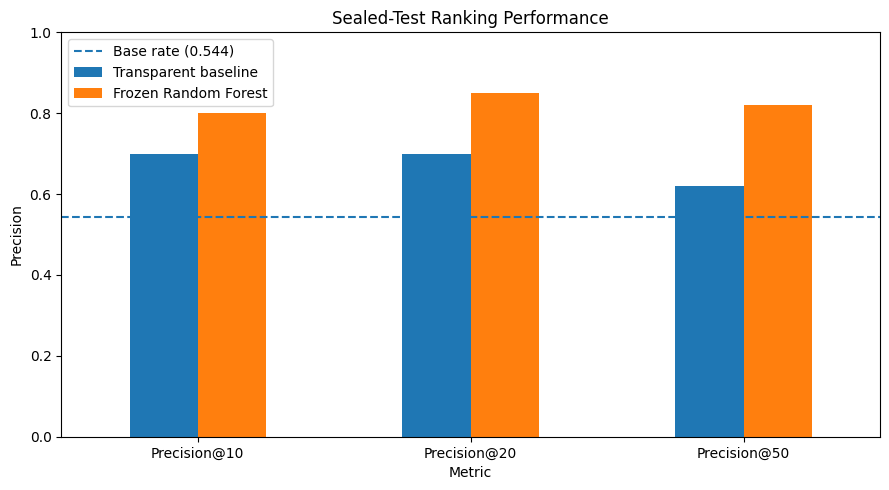

Saved: work/outputs/figures/sealed_test_precision_comparison.png


In [28]:
# ---------------------------------------------------------
# Figure 1 — Sealed-test ranking performance
# ---------------------------------------------------------

plot_metrics = sealed_results.set_index("method")[
    [
        "precision_at_10",
        "precision_at_20",
        "precision_at_50"
    ]
].T

plot_metrics.index = [
    "Precision@10",
    "Precision@20",
    "Precision@50"
]

ax = plot_metrics.plot(
    kind="bar",
    figsize=(9, 5)
)

ax.axhline(
    y=float(y_test.mean()),
    linestyle="--",
    linewidth=1.5,
    label=f"Base rate ({y_test.mean():.3f})"
)

ax.set_title(
    "Sealed-Test Ranking Performance"
)
ax.set_xlabel("Metric")
ax.set_ylabel("Precision")
ax.set_ylim(0, 1.0)

plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()

fig1_path = (
    f"{FIGURE_DIR}/"
    "sealed_test_precision_comparison.png"
)

plt.savefig(
    fig1_path,
    dpi=180,
    bbox_inches="tight"
)

plt.show()

print("Saved:", fig1_path)

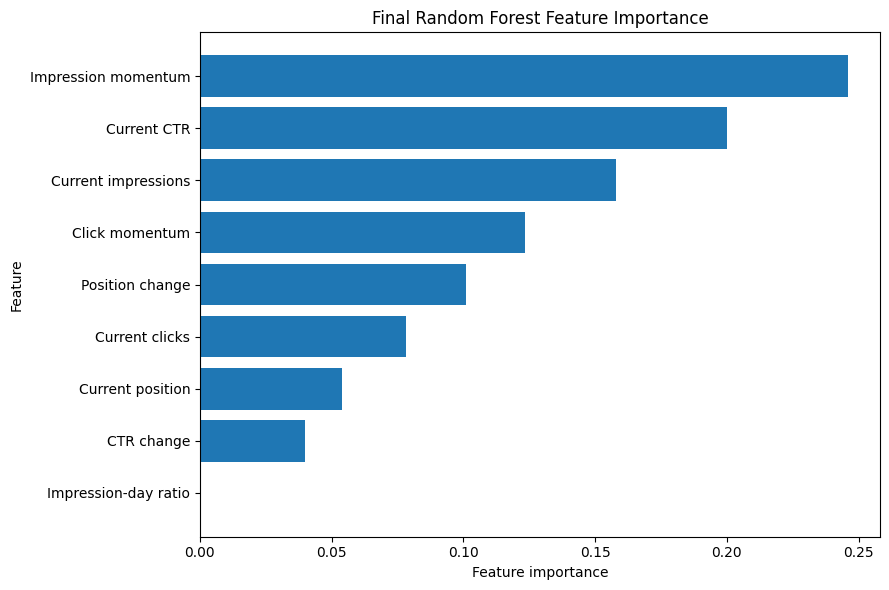

Saved: work/outputs/figures/final_feature_importance.png


,feature,importance
5,impression_momentum_log,0.2458
2,current_ctr_pct_feature,0.1999
0,log_avg_daily_impressions,0.1580
6,click_momentum_log,0.1235
7,position_change,0.1009
1,log_avg_daily_clicks,0.0780
3,current_avg_position_feature,0.0539
8,ctr_change,0.0399
4,impression_day_ratio,0.0000


In [29]:
# ---------------------------------------------------------
# Figure 2 — Final Random Forest feature importance
# ---------------------------------------------------------

final_rf_estimator = (
    final_rf_model.named_steps["model"]
)

final_importance_df = pd.DataFrame({
    "feature": FEATURES,
    "importance":
        final_rf_estimator.feature_importances_
}).sort_values(
    "importance",
    ascending=True
)

feature_labels = {
    "log_avg_daily_impressions":
        "Current impressions",
    "log_avg_daily_clicks":
        "Current clicks",
    "current_ctr_pct_feature":
        "Current CTR",
    "current_avg_position_feature":
        "Current position",
    "impression_day_ratio":
        "Impression-day ratio",
    "impression_momentum_log":
        "Impression momentum",
    "click_momentum_log":
        "Click momentum",
    "position_change":
        "Position change",
    "ctr_change":
        "CTR change",
}

final_importance_df["display_feature"] = (
    final_importance_df["feature"]
    .map(feature_labels)
)

plt.figure(figsize=(9, 6))

plt.barh(
    final_importance_df["display_feature"],
    final_importance_df["importance"]
)

plt.title(
    "Final Random Forest Feature Importance"
)
plt.xlabel("Feature importance")
plt.ylabel("Feature")

plt.tight_layout()

fig2_path = (
    f"{FIGURE_DIR}/"
    "final_feature_importance.png"
)

plt.savefig(
    fig2_path,
    dpi=180,
    bbox_inches="tight"
)

plt.show()

print("Saved:", fig2_path)

final_importance_df[
    [
        "feature",
        "importance"
    ]
].sort_values(
    "importance",
    ascending=False
).round(4)

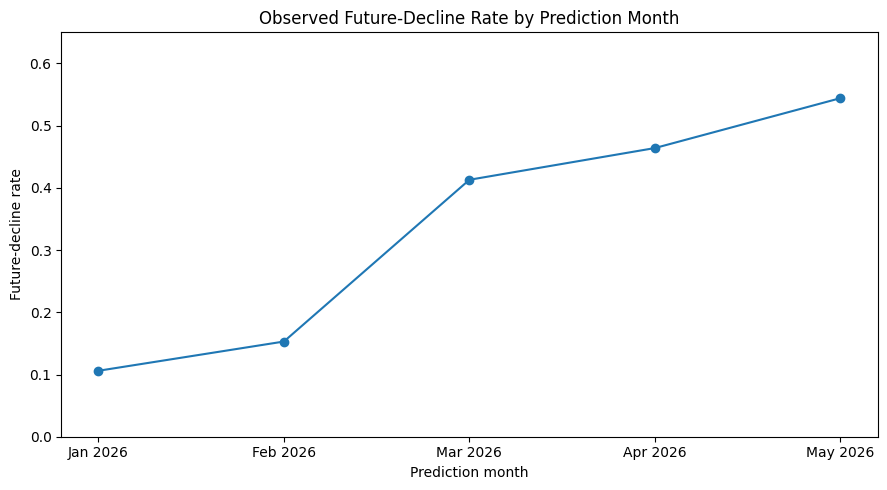

Saved: work/outputs/figures/decline_rate_over_time.png


,prediction_month,decline_rate
0,2026-01-01,0.106000
1,2026-02-01,0.153000
2,2026-03-01,0.413000
3,2026-04-01,0.464000
4,2026-05-01,0.544185


In [30]:
# ---------------------------------------------------------
# Figure 3 — Future-decline prevalence over time
# ---------------------------------------------------------

temporal_rates = (
    development_summary[
        [
            "prediction_month",
            "decline_rate"
        ]
    ]
    .copy()
)

sealed_rate_row = pd.DataFrame({
    "prediction_month": [
        pd.Timestamp("2026-05-01")
    ],
    "decline_rate": [
        float(y_test.mean())
    ]
})

temporal_rates = pd.concat(
    [
        temporal_rates,
        sealed_rate_row
    ],
    ignore_index=True
)

temporal_rates = (
    temporal_rates
    .sort_values("prediction_month")
)

temporal_rates["month_label"] = (
    temporal_rates["prediction_month"]
    .dt.strftime("%b 2026")
)

plt.figure(figsize=(9, 5))

plt.plot(
    temporal_rates["month_label"],
    temporal_rates["decline_rate"],
    marker="o"
)

plt.title(
    "Observed Future-Decline Rate by Prediction Month"
)
plt.xlabel("Prediction month")
plt.ylabel("Future-decline rate")
plt.ylim(0, 0.65)

plt.tight_layout()

fig3_path = (
    f"{FIGURE_DIR}/"
    "decline_rate_over_time.png"
)

plt.savefig(
    fig3_path,
    dpi=180,
    bbox_inches="tight"
)

plt.show()

print("Saved:", fig3_path)

temporal_rates[
    [
        "prediction_month",
        "decline_rate"
    ]
]

In [31]:
# ---------------------------------------------------------
# Public-safe results table for paper
# ---------------------------------------------------------

paper_results = sealed_results[
    [
        "method",
        "base_rate",
        "precision_at_10",
        "precision_at_20",
        "precision_at_50",
        "lift_at_50",
        "average_precision",
        "roc_auc",
    ]
].copy()

paper_results_path = (
    "work/outputs/"
    "capstone_paper_results.csv"
)

paper_results.to_csv(
    paper_results_path,
    index=False
)

display(paper_results)

print(
    "Saved:",
    paper_results_path
)

,method,base_rate,precision_at_10,precision_at_20,precision_at_50,lift_at_50,average_precision,roc_auc
0,Transparent baseline,0.544,0.7,0.70,0.62,1.139,0.574,0.524
1,Frozen Random Forest,0.544,0.8,0.85,0.82,1.507,0.644,0.617


Saved: work/outputs/capstone_paper_results.csv


# **Closing communication artifacts**

**5-minute demo outline**
**0:00–0:45 — Problem:** Editors cannot review every page, so the project asks whether historical search-performance signals can rank pages that are more likely to experience a meaningful decline in the following month.

**0:45–1:30 — Data:** I used the FlyRank full warehouse and aggregated daily GSC performance to monthly page-level observations. Features came only from the prediction month and the previous month. A future decline was defined as at least a 30% reduction in average daily impressions in the following month.

**1:30–2:30 — Method:** I used a time-aware development and validation design, compared Logistic Regression and Random Forest against a transparent momentum-based baseline, and selected the Random Forest using the pre-specified Precision@50 metric. June remained sealed until the model specification was frozen.

**2:30–3:30 — Result:** On the sealed May→June holdout, the base decline rate was 54.4%. The transparent baseline achieved Precision@50 of 62.0%, while the frozen Random Forest achieved 82.0%, meaning 41 of its top 50 review candidates met the future-decline definition. The model also achieved 1.507× lift at 50 over the base rate.

**3:30–4:20 — Interpretation:** Position change, CTR, click momentum, and impression momentum were among the model's strongest signals. These are predictive associations, not causal explanations.

**4:20–5:00 — Action and limitations:** The output is a ranked priority-review queue with reason codes. Editors should investigate the recommended pages before changing content. The model does not predict Google's algorithm and does not show that refreshing a page causes better performance.

**Social-post cut**
I completed my Machine Learning capstone with FlyRank, building a time-aware ranking system to prioritize content pages at risk of future search-visibility decline. Using historical search-performance signals and a sealed future holdout, the frozen Random Forest achieved 82% Precision@50, compared with 62% for a transparent baseline, on a test population with a 54.4% decline base rate. The project focused heavily on leakage control, temporal validation, honest baseline comparison, error analysis, and decision-support rather than causal claims.

**Employer-facing summary**
I built an end-to-end machine-learning ranking system on FlyRank's large search-performance warehouse to prioritize pages at risk of future visibility decline. I designed leakage-safe historical features, time-aware validation, a transparent baseline, and a sealed future holdout, where the selected Random Forest achieved 82% Precision@50 versus 62% for the baseline. The final output is a reproducible ranked review queue with interpretable reason codes and explicit limitations for human decision-support.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
